# 10. Duboko učenje

## Šta je duboko učenje

| oblast | opis |
|---|---|
| **Veštačka inteligencija (AI)** | razvoj inteligentnih sistema sposobnih za učenje, zaključivanje i rešavanje problema |
| **Mašinsko učenje (ML)** | podoblast AI; modeli uče obrasce iz podataka bez eksplicitnih pravila |
| **Duboko učenje (DL)** | podoblast ML; **neuronske mreže sa više slojeva** za automatsko učenje reprezentacija |
| **Generativna VI** | grana DL koja se bavi generisanjem novih podataka (tekst, slike, zvuk) |

## Ključni faktori uspeha dubokog učenja

1. **Velike količine podataka** — digitalizacija, internet, senzori, društvene mreže
2. **Povećana računarska snaga** — GPU, paralelno računanje, cloud
3. **Efikasni algoritmi treniranja** — backpropagation i poboljšane metode optimizacije
4. **Poboljšane arhitekture** — stabilnije i dublje mreže
5. **Razvoj softverskih alata** — biblioteke i okviri

## Tipovi neuronskih mreža

| tip | primena |
|---|---|
| **MLP** (višeslojne) | tabelarni podaci, opšta namena |
| **CNN** (konvolucione) | slike i prostorni podaci |
| **RNN / LSTM / GRU** | sekvence i vremenski nizovi |
| **Transformers** | mehanizam pažnje; dominantni u NLP-u i multimodalnim sistemima |
| **Generativne** | generisanje novih podataka |

In [1]:
import warnings, os
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

plt.rcParams["figure.figsize"] = (9, 4.5); plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3
RS = 42
np.random.seed(RS); tf.random.set_seed(RS)
print(f"TensorFlow {tf.__version__}")

TensorFlow 2.21.0


## Logistička regresija kao jedan neuron

Logistička regresija se može posmatrati kao **najjednostavnija neuronska mreža** — jedan
neuron koji:

1. prima ulazni vektor $x \in \mathbb{R}^{n_x}$
2. računa **linearni deo**: $z = w^\top x + b$
3. primenjuje **aktivacionu funkciju**: $\hat y = a = \sigma(z)$

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Parametri koji se uče su **težine** $w$ i **bias** $b$.

In [2]:
bc = load_breast_cancer()
Xtr, Xte, ytr, yte = train_test_split(bc.data, bc.target, test_size=0.25,
                                      random_state=RS, stratify=bc.target)
sc = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)

# 1. logisticka regresija iz sklearn-a
log = LogisticRegression(max_iter=5000).fit(Xtr_s, ytr)

# 2. ISTA stvar kao mreza sa jednim neuronom
neuron = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(Xtr_s.shape[1],)),
    tf.keras.layers.Dense(1, activation="sigmoid"),      # z = w'x + b, pa sigmoid
])
neuron.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
neuron.fit(Xtr_s, ytr, epochs=120, batch_size=32, verbose=0)

print(f"sklearn LogisticRegression : {log.score(Xte_s, yte):.4f}")
print(f"Keras — jedan neuron       : {neuron.evaluate(Xte_s, yte, verbose=0)[1]:.4f}")
print(f"\nBroj parametara neurona: {neuron.count_params()}  = {Xtr_s.shape[1]} tezina + 1 bias")

sklearn LogisticRegression : 0.9860
Keras — jedan neuron       : 0.9720

Broj parametara neurona: 31  = 30 tezina + 1 bias


## Funkcija greške i funkcija troška

**Funkcija greške (loss)** meri grešku za **jedan** trening primer.

| funkcija | formula | kada |
|---|---|---|
| **Kvadratna greška** | $\mathcal{L} = \tfrac{1}{2}(\hat y - y)^2$ | **regresija** |
| **Cross-entropy** | $\mathcal{L} = -\big[y\log\hat y + (1-y)\log(1-\hat y)\big]$ | **binarna klasifikacija** |

Kvadratna greška nije pogodna za klasifikaciju sa sigmoidom; cross-entropy daje stabilnije
i efikasnije učenje.

### Zašto log „kažnjava" samouverene greške

Ako je pravi odgovor $y = 1$:

| predikcija | $\log \hat y$ | greška |
|---|---|---|
| $\hat y \approx 1$ | $\approx 0$ | mala |
| $\hat y \approx 0$ | $\to -\infty$ | **ogromna** |

Model se **strogo kažnjava** kada je veoma siguran, a pogrešan.

**Funkcija troška (cost)** je **prosek** funkcije greške nad celim trening skupom:

$$J(w, b) = \frac{1}{m}\sum_{i=1}^{m} \mathcal{L}\big(\hat y^{(i)}, y^{(i)}\big)$$

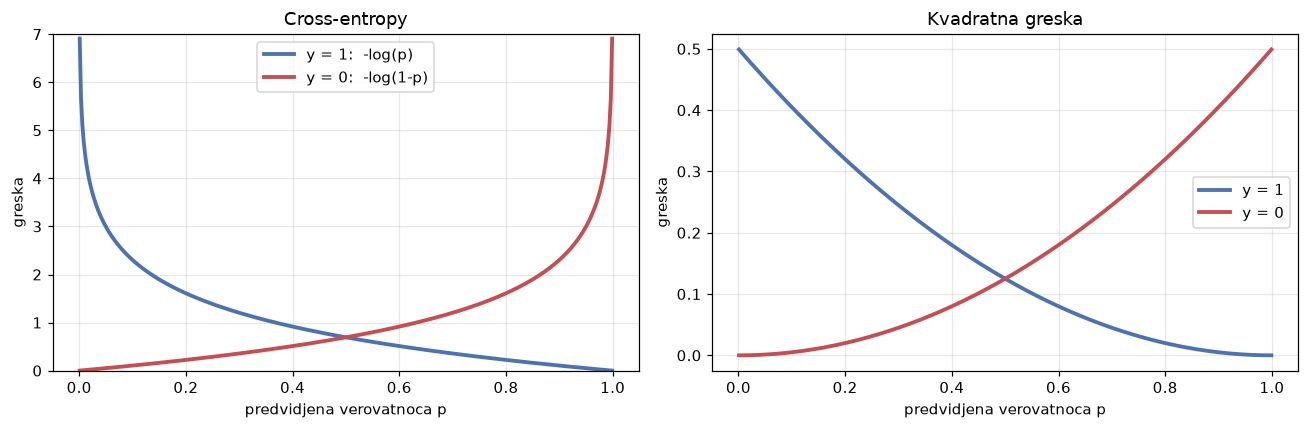

Kada je y=1, a model kaze p=0.01:
   cross-entropy : 4.605   <- ogromna kazna
   kvadratna     : 0.490   <- blaga, gradijent skoro nestaje


In [3]:
p = np.linspace(0.001, 0.999, 400)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(p, -np.log(p), lw=2.5, color="#4C72B0", label="y = 1:  -log(p)")
ax[0].plot(p, -np.log(1-p), lw=2.5, color="#C44E52", label="y = 0:  -log(1-p)")
ax[0].set_xlabel("predvidjena verovatnoca p"); ax[0].set_ylabel("greska")
ax[0].set_title("Cross-entropy"); ax[0].legend(); ax[0].set_ylim(0, 7)

ax[1].plot(p, 0.5*(p-1)**2, lw=2.5, color="#4C72B0", label="y = 1")
ax[1].plot(p, 0.5*p**2, lw=2.5, color="#C44E52", label="y = 0")
ax[1].set_xlabel("predvidjena verovatnoca p"); ax[1].set_ylabel("greska")
ax[1].set_title("Kvadratna greska"); ax[1].legend()
plt.tight_layout(); plt.show()

print("Kada je y=1, a model kaze p=0.01:")
print(f"   cross-entropy : {-np.log(0.01):.3f}   <- ogromna kazna")
print(f"   kvadratna     : {0.5*(0.01-1)**2:.3f}   <- blaga, gradijent skoro nestaje")

## Gradient Descent

Iterativni algoritam optimizacije koji traži vrednosti $w$ i $b$ koje **minimizuju
funkciju troška**.

**Ideja:** izračunaj gradijent funkcije troška, pa pomeri parametre u smeru **suprotnom**
od gradijenta.

$$w := w - \alpha \frac{\partial J(w,b)}{\partial w} \qquad
b := b - \alpha \frac{\partial J(w,b)}{\partial b}$$

gde je $\alpha$ **korak učenja** (learning rate).

- **veliki gradijent** → veliki korak
- **mali gradijent** → mali korak

Iteracijama se približavamo minimumu. Gradient Descent je osnovni mehanizam učenja u
neuronskim mrežama.

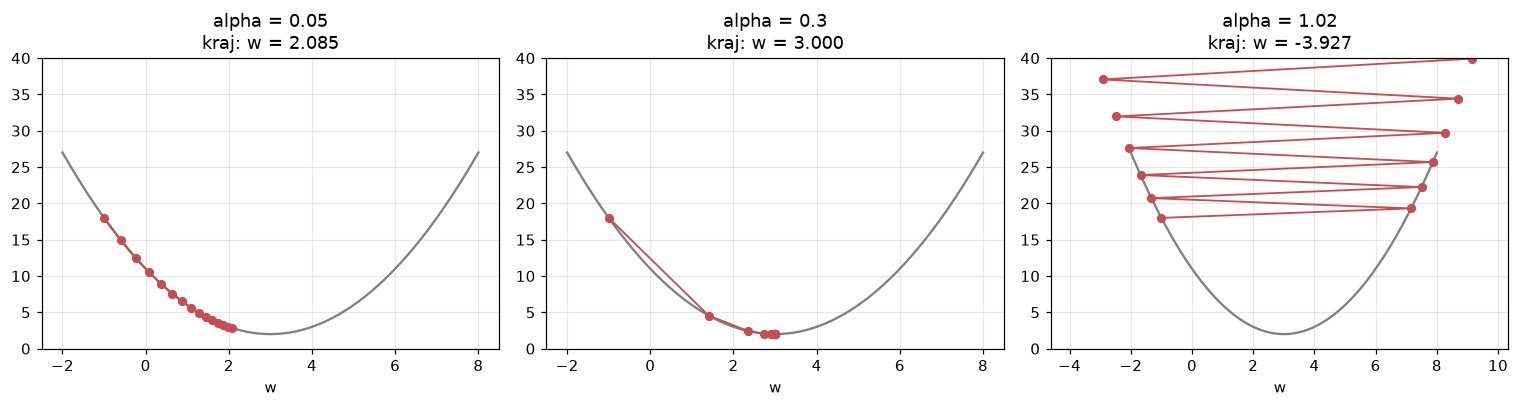

alpha premali -> sporo. alpha dobar -> brzo konvergira.
alpha prevelik -> koraci preskacu minimum i DIVERGIRA.


In [4]:
def J(w): return (w - 3) ** 2 + 2          # jednostavna funkcija troska
def dJ(w): return 2 * (w - 3)              # njen gradijent

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
ww = np.linspace(-2, 8, 200)
for a, alfa in zip(ax, (0.05, 0.3, 1.02)):
    a.plot(ww, J(ww), color="gray", lw=1.5)
    w = -1.0
    putanja = [w]
    for _ in range(14):
        w = w - alfa * dJ(w)
        putanja.append(w)
    putanja = np.array(putanja)
    a.plot(putanja, J(putanja), "o-", color="#C44E52", ms=5, lw=1.2)
    a.set_title(f"alpha = {alfa}\nkraj: w = {w:.3f}")
    a.set_xlabel("w"); a.set_ylim(0, 40)
plt.tight_layout(); plt.show()
print("alpha premali -> sporo. alpha dobar -> brzo konvergira.")
print("alpha prevelik -> koraci preskacu minimum i DIVERGIRA.")

## Računski graf, forward i backward propagation

Izračunavanja u mreži se predstavljaju **računskim grafom**.

| korak | šta radi |
|---|---|
| **Forward propagation** | izračunavanje izlaza mreže prolaskom ulaza kroz slojeve |
| **Backpropagation** | izračunavanje gradijenata funkcije troška u odnosu na parametre, propagacijom **unazad** |

Računski graf prikazuje redosled operacija, omogućava efikasno računanje gradijenata i
ažuriranje težina pomoću Gradient Descent-a.

### Računanje u sloju

Svaki neuron računa:
$$z_i^{[l]} = \big(w_i^{[l]}\big)^\top x + b_i^{[l]}, \qquad a_i^{[l]} = \sigma\big(z_i^{[l]}\big)$$

Neuroni u istom sloju rade **paralelno**, a izlaz jednog sloja je **ulaz** sledećem.

In [5]:
# forward i backward rucno, na jednom neuronu, preko GradientTape
x = tf.constant([[1.0, 2.0]])
y = tf.constant([[1.0]])
w = tf.Variable([[0.5], [-0.3]])
b = tf.Variable([[0.1]])

with tf.GradientTape() as tape:
    z = tf.matmul(x, w) + b                       # FORWARD: linearni deo
    a = tf.sigmoid(z)                             # FORWARD: aktivacija
    L = -(y * tf.math.log(a) + (1-y) * tf.math.log(1-a))    # cross-entropy

dw, db = tape.gradient(L, [w, b])                 # BACKWARD

print(f"FORWARD:")
print(f"   z = w'x + b   = {z.numpy()[0,0]:.4f}")
print(f"   a = sigmoid(z)= {a.numpy()[0,0]:.4f}")
print(f"   L (loss)      = {L.numpy()[0,0]:.4f}")
print(f"\nBACKWARD (gradijenti):")
print(f"   dL/dw = {dw.numpy().ravel().round(4)}")
print(f"   dL/db = {db.numpy().ravel().round(4)}")
print(f"\nAzuriranje sa alpha=0.1:  w_novo = {(w - 0.1*dw).numpy().ravel().round(4)}")

FORWARD:
   z = w'x + b   = -0.0000
   a = sigmoid(z)= 0.5000
   L (loss)      = 0.6931

BACKWARD (gradijenti):
   dL/dw = [-0.5 -1. ]
   dL/db = [-0.5]

Azuriranje sa alpha=0.1:  w_novo = [ 0.55 -0.2 ]


## Aktivacione funkcije

Aktivacione funkcije uvode **nelinearnost**. Bez njih bi neuronska mreža bila
**ekvivalentna linearnom modelu**, bez obzira na broj slojeva.

| funkcija | formula | izlaz | gde se koristi |
|---|---|---|---|
| **Sigmoid** | $\sigma(z) = \dfrac{1}{1+e^{-z}}$ | $(0, 1)$ | izlazni sloj, binarna klasifikacija |
| **ReLU** | $\max(0, z)$ | $[0, \infty)$ | **najčešća u skrivenim slojevima** |
| **Tanh** | $\tanh(z)$ | $(-1, 1)$ | centrirana oko nule, ređe od ReLU |

**Softmax** se koristi u izlaznom sloju za **višeklasnu** klasifikaciju:

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

Pretvara izlaze u verovatnoće u $(0,1)$ čiji je **zbir 1**.

> **Sigmoid bira između dve opcije, Softmax između više.**

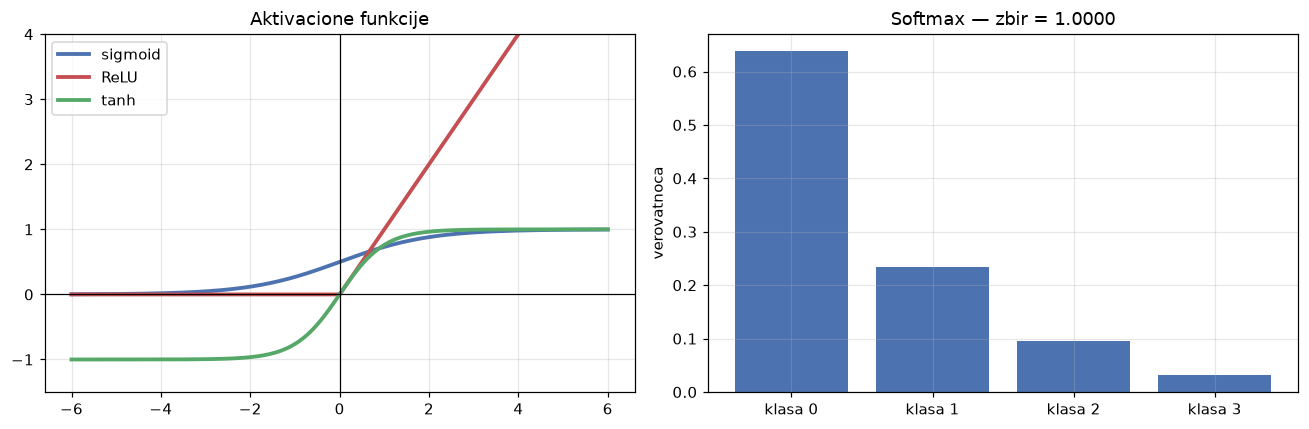

Logiti  : [ 2.   1.   0.1 -1. ]
Softmax : [0.6381 0.2347 0.0954 0.0318]   zbir = 1.000000


In [6]:
z = np.linspace(-6, 6, 300)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for ime, f, boja in [("sigmoid", 1/(1+np.exp(-z)), "#4C72B0"),
                     ("ReLU", np.maximum(0, z), "#C44E52"),
                     ("tanh", np.tanh(z), "#55A868")]:
    ax[0].plot(z, f, lw=2.5, label=ime, color=boja)
ax[0].axhline(0, color="k", lw=0.8); ax[0].axvline(0, color="k", lw=0.8)
ax[0].set_title("Aktivacione funkcije"); ax[0].legend(); ax[0].set_ylim(-1.5, 4)

logiti = np.array([2.0, 1.0, 0.1, -1.0])
sm = np.exp(logiti) / np.exp(logiti).sum()
ax[1].bar(range(4), sm, color="#4C72B0")
ax[1].set_xticks(range(4)); ax[1].set_xticklabels([f"klasa {i}" for i in range(4)])
ax[1].set_ylabel("verovatnoca"); ax[1].set_title(f"Softmax — zbir = {sm.sum():.4f}")
plt.tight_layout(); plt.show()
print(f"Logiti  : {logiti}")
print(f"Softmax : {sm.round(4)}   zbir = {sm.sum():.6f}")

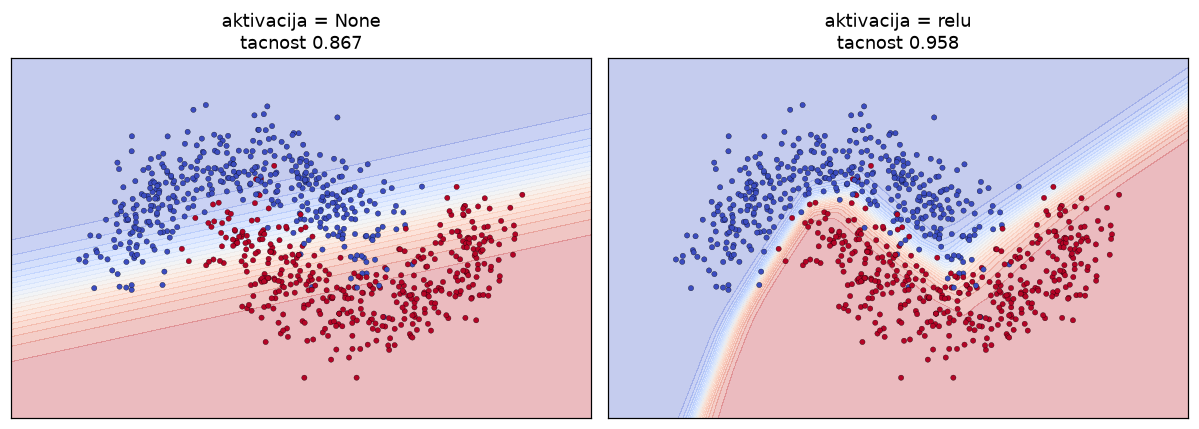

Bez aktivacije granica je PRAVA — tri linearna sloja daju opet linearan model.


In [7]:
# dokaz: bez aktivacije mreza je samo linearan model
Xm, ym = make_moons(n_samples=800, noise=0.22, random_state=RS)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.3, random_state=RS)

def napravi(aktivacija):
    m = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(2,)),
        tf.keras.layers.Dense(32, activation=aktivacija),
        tf.keras.layers.Dense(32, activation=aktivacija),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return m

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, akt in zip(ax, [None, "relu"]):
    m = napravi(akt)
    m.fit(Xm_tr, ym_tr, epochs=80, batch_size=32, verbose=0)
    XX, YY = np.meshgrid(np.linspace(-2, 3, 200), np.linspace(-1.5, 2, 200))
    Z = m.predict(np.c_[XX.ravel(), YY.ravel()], verbose=0).reshape(XX.shape)
    a.contourf(XX, YY, Z, alpha=0.3, cmap="coolwarm", levels=20)
    a.scatter(Xm[:, 0], Xm[:, 1], c=ym, s=12, cmap="coolwarm", edgecolor="k", linewidth=0.2)
    t = m.evaluate(Xm_te, ym_te, verbose=0)[1]
    a.set_title(f"aktivacija = {akt}\ntacnost {t:.3f}")
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()
print("Bez aktivacije granica je PRAVA — tri linearna sloja daju opet linearan model.")

## Parametri i hiperparametri u neuronskim mrežama

| **parametri** (uče se) | **hiperparametri** (biramo ih) |
|---|---|
| težine $W$ | broj skrivenih slojeva |
| bias vrednosti $b$ | broj neurona po sloju |
| | funkcija aktivacije |
| | learning rate $\alpha$ |
| | broj epoha |
| | batch size |

Parametri se ažuriraju optimizacionim algoritmom (Gradient Descent, SGD, Momentum,
RMSProp, **Adam**).

## Overfitting i underfitting kod mreža

| | trening greška | test greška |
|---|---|---|
| **underfitting** | visoka | visoka |
| **overfitting** | **vrlo niska** | visoka |

### Pet tehnika za smanjenje overfittinga

1. **Više podataka** — veći i raznovrsniji skup
2. **Regularizacija (L1, L2)** — ograničava vrednosti težina
3. **Dropout** — nasumično isključuje neurone tokom treniranja
4. **Early stopping** — prekid kada validaciona greška počne da raste
5. **Smanjenje složenosti** — manje slojeva ili neurona

### L1 i L2 regularizacija

$$J_{\text{reg}} = J + \lambda \sum w^2 \quad (\text{L2, Ridge}) \qquad
J_{\text{reg}} = J + \lambda \sum \lvert w \rvert \quad (\text{L1, Lasso})$$

| | efekat |
|---|---|
| **L2** | kažnjava velike težine; najčešća u mrežama |
| **L1** | podstiče **retke** modele, može „ugasiti" težine na $\approx 0$ |

### Dropout

Nasumično **isključuje neurone tokom treniranja**, pa se mreža ne može osloniti na
pojedinačne neurone. Tokom **testiranja su svi neuroni aktivni**.
Tipične vrednosti: **0.2 – 0.5**.

### Early stopping

Prati se greška na trening i validacionom skupu. Kada validaciona greška prestane da opada
ili počne da raste, treniranje se zaustavlja. Ne zahteva izmene arhitekture.

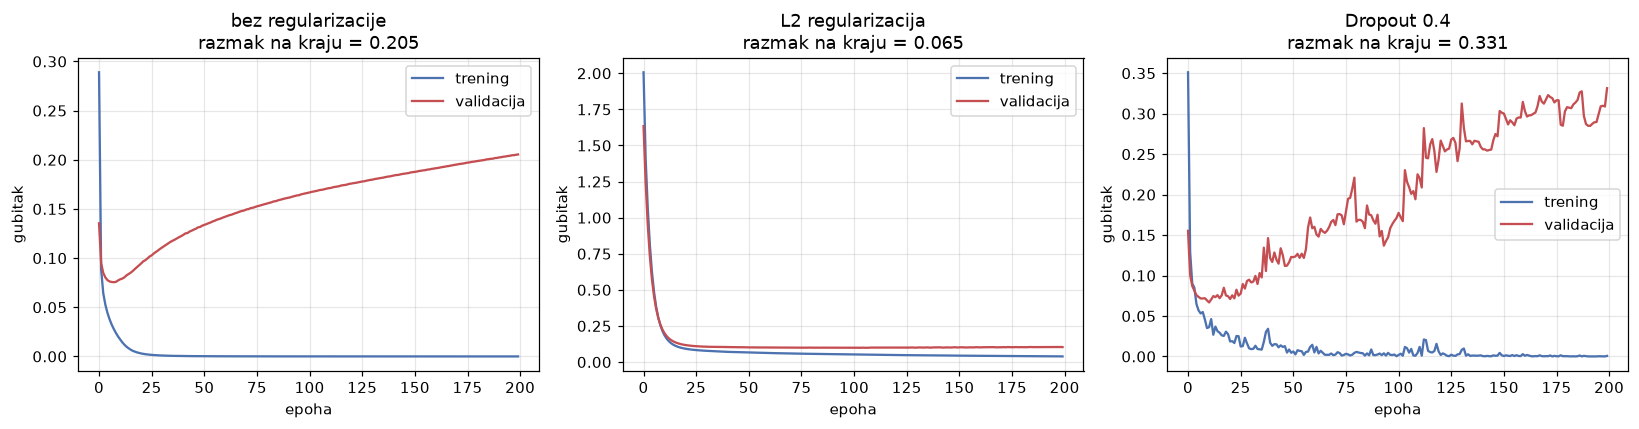

Veci razmak izmedju krivih = jaci overfitting.


In [8]:
def treniraj(ime, slojevi, epohe=200, **fit_kw):
    m = tf.keras.Sequential([tf.keras.layers.Input(shape=(Xtr_s.shape[1],))] + slojevi)
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    h = m.fit(Xtr_s, ytr, validation_data=(Xte_s, yte), epochs=epohe,
              batch_size=16, verbose=0, **fit_kw)
    return ime, m, h

D = tf.keras.layers.Dense
Dr = tf.keras.layers.Dropout
l2 = tf.keras.regularizers.l2

rezultati = [
    treniraj("bez regularizacije", [D(128, activation="relu"), D(128, activation="relu"), D(1, activation="sigmoid")]),
    treniraj("L2 regularizacija", [D(128, activation="relu", kernel_regularizer=l2(0.01)),
                                   D(128, activation="relu", kernel_regularizer=l2(0.01)), D(1, activation="sigmoid")]),
    treniraj("Dropout 0.4", [D(128, activation="relu"), Dr(0.4),
                             D(128, activation="relu"), Dr(0.4), D(1, activation="sigmoid")]),
]

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, (ime, m, h) in zip(ax, rezultati):
    a.plot(h.history["loss"], label="trening", color="#4C72B0")
    a.plot(h.history["val_loss"], label="validacija", color="#C44E52")
    razmak = h.history["val_loss"][-1] - h.history["loss"][-1]
    a.set_title(f"{ime}\nrazmak na kraju = {razmak:.3f}")
    a.set_xlabel("epoha"); a.set_ylabel("gubitak"); a.legend()
plt.tight_layout(); plt.show()
print("Veci razmak izmedju krivih = jaci overfitting.")

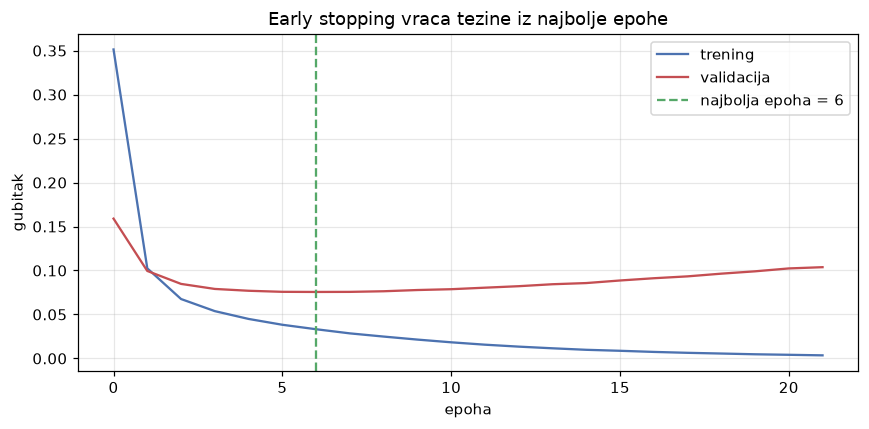

Treniranje prekinuto posle 22 epoha (limit je bio 300).
Tacnost na testu: 0.9650


In [9]:
# early stopping
rano = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15,
                                        restore_best_weights=True)
ime, m, h = treniraj("early stopping", [D(128, activation="relu"), D(128, activation="relu"),
                                        D(1, activation="sigmoid")],
                     epohe=300, callbacks=[rano])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(h.history["loss"], label="trening", color="#4C72B0")
ax.plot(h.history["val_loss"], label="validacija", color="#C44E52")
naj = int(np.argmin(h.history["val_loss"]))
ax.axvline(naj, color="#55A868", ls="--", label=f"najbolja epoha = {naj}")
ax.set_xlabel("epoha"); ax.set_ylabel("gubitak"); ax.legend()
ax.set_title("Early stopping vraca tezine iz najbolje epohe")
plt.tight_layout(); plt.show()
print(f"Treniranje prekinuto posle {len(h.history['loss'])} epoha (limit je bio 300).")
print(f"Tacnost na testu: {m.evaluate(Xte_s, yte, verbose=0)[1]:.4f}")

## Ograničenja neuronskih mreža

1. **Potreba za velikom količinom podataka**
2. **Veća računarska zahtevnost**
3. **Teža interpretabilnost** — crna kutija
4. **Osetljivost na hiperparametre**

> **Neuronske mreže nisu uvek najbolji izbor.** Na tabelarnim podacima srednje veličine
> ansambl metode (predavanje 12) često daju bolji rezultat uz manje truda.

In [10]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300, random_state=RS).fit(Xtr, ytr)
print(f"Neuronska mreza (MLP) : {m.evaluate(Xte_s, yte, verbose=0)[1]:.4f}")
print(f"Random Forest         : {rf.score(Xte, yte):.4f}")
print(f"\nParametara u mrezi: {m.count_params():,}")
print("-> Na tabelarnim podacima ove velicine, RF je jednako dobar uz mnogo manje podesavanja.")

Neuronska mreza (MLP) : 0.9650
Random Forest         : 0.9580

Parametara u mrezi: 20,609
-> Na tabelarnim podacima ove velicine, RF je jednako dobar uz mnogo manje podesavanja.
